In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

data1 = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.1%20data%20integration/data/issues1.csv', index_col=0)

data2 = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.1%20data%20integration/data/issues2.csv', index_col=0)

data3 = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.1%20data%20integration/data/issues4.csv', index_col=0)
data3.head()

,Unique id,channel_name,category,Sub-category,Issue_reported at,issue_responded,Survey_response_Date,Agent,CSAT Score
0,3350ccee-ead7-40fa-80c6-cc7b5e6e345a,Inbound,Returns,Reverse Pickup Enquiry,"August 27, 2023, 08:28:00 AM","August 27, 2023, 08:29:00 AM","August 27, 2023, 12:00:00 AM",Terry Young,5
1,4a88df6e-aafb-477a-bd8e-63ffc34c1a43,Inbound,Returns,Wrong,"December 08, 2023, 03:04:00 PM","August 12, 2023, 03:19:00 PM","August 12, 2023, 12:00:00 AM",Brenda Cox,4
2,7b5dbea2-2370-490a-8fef-4c5f7c52a4cc,Inbound,Returns,Reverse Pickup Enquiry,"August 13, 2023, 12:45:00 PM","August 13, 2023, 01:02:00 PM","August 13, 2023, 12:00:00 AM",Brian Mcguire,5
3,c6d4401e-a4ef-4de0-af68-a8755b928f5f,Inbound,Refund Related,Refund Enquiry,"June 08, 2023, 06:07:00 PM","August 06, 2023, 06:08:00 PM","August 06, 2023, 12:00:00 AM",Dr. Heather Lewis,5
4,423bd17e-e944-4f6e-beff-9c97fa325d9e,Inbound,Returns,Reverse Pickup Enquiry,"April 08, 2023, 10:05:00 PM","August 04, 2023, 10:08:00 PM","August 04, 2023, 12:00:00 AM",Kristin Adams,5


In [2]:
data1.shape, data2.shape, data3.shape

data2 = data2.rename(columns={
    'channel_name': 'Channel',
    'Reported at': 'Issue_reported_Date',
    'Responded at': 'Issue_responded_Date',
    'Survey responded at': 'Survey_response_Date',
})

data2['Issue_reported_Date'] = pd.to_datetime(data2['Issue_reported_Date'])
data2['Issue_responded_Date'] = pd.to_datetime(data2['Issue_responded_Date'])
data2['Survey_response_Date'] = pd.to_datetime(data2['Survey_response_Date'], format='%d %m %Y')

data1['Issue_reported_Date'] = pd.to_datetime(data2['Issue_reported_Date'])
data1['Issue_responded_Date'] = pd.to_datetime(data2['Issue_responded_Date'])
data1['Survey_response_Date'] = pd.to_datetime(data2['Survey_response_Date'], format='%d %m %Y')

data12 = pd.concat([data1, data2])

# fig, ax = plt.subplots(6, 2)
# ax = ax.flatten()
# sns.histplot(data12['Id'], ax=ax[1], kde=True)

# for n, i in enumerate(data12):
#     sns.histplot(data12[i], ax=ax[n], kde=True)

data3 = data3.rename(columns={
    'Unique id': 'Id',
    'channel_name': 'Channel',
    'Issue_reported at': 'Issue_reported_Date',
    'issue_responded': 'Issue_responded_Date',
    'Agent': 'Agent_name'
})

data3['Issue_reported_Date'] = pd.to_datetime(data2['Issue_reported_Date'])
data3['Issue_responded_Date'] = pd.to_datetime(data2['Issue_responded_Date'])
data3['Survey_response_Date'] = pd.to_datetime(data2['Survey_response_Date'], format='%d %m %Y')

data3['Agent_name'] = data3['Agent_name'].apply(lambda x: f'{x.split()[0][0]}. {x.split()[1]}' if isinstance(x, str) else np.NAN)

data123 = pd.concat([data12, data3])

data123

C:\Users\Artem\AppData\Local\Temp\ipykernel_27652\1655386524.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data2['Issue_reported_Date'] = pd.to_datetime(data2['Issue_reported_Date'])
C:\Users\Artem\AppData\Local\Temp\ipykernel_27652\1655386524.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data2['Issue_responded_Date'] = pd.to_datetime(data2['Issue_responded_Date'])


,Id,Channel,category,Sub-category,Customer Remarks,Order_id,Issue_reported_Date,Issue_responded_Date,Survey_response_Date,Agent_name,CSAT Score
0,8c910188-c387-4a1b-8d90-24379ec8c047,Inbound,Returns,Reverse Pickup Enquiry,Very happy,NaN,2023-08-21 21:01:00,2023-08-21 21:04:00,2023-08-21,J. Blackwell,1
1,99d5ee06-8d2a-4754-bd17-ed235c70bf33,Inbound,Returns,Return request,Thoda jalfi replacement approve kijiye mera,89e6448f-9a48-4892-a09c-b47e0d8a87fe,2023-08-18 21:20:00,2023-08-18 21:20:00,2023-08-18,M. Wilson,4
2,336020c5-dc97-488f-8f16-ed33ed04e5fc,Inbound,Returns,Damaged,Technician not visit the RO and without visit ...,15476f9a-35cc-4f33-ae33-8d9cd6ecb1a6,2023-08-24 21:57:00,2023-08-24 21:58:00,2023-08-24,A. Smith,5
3,22c5643c-3d54-487c-8863-c57e198a70be,Inbound,Returns,Fraudulent User,madam ne mera problem solve kar Diya hai . t...,NaN,2023-08-28 23:38:00,2023-08-29 05:55:00,2023-08-29,A. Berry,5
4,abd330a8-f3e2-4b7a-b14a-4ed35c4ec023,Inbound,Returns,Fraudulent User,Gjjjzjxgxteuhxgxe5xhxh,NaN,2023-08-30 11:03:00,2023-08-30 11:04:00,2023-08-30,S. Taylor,5
...,...,...,...,...,...,...,...,...,...,...,...
13138,ea09d98a-63d4-4143-8035-0e92c468baca,Inbound,Payments related,Online Payment Issues,NaN,NaN,2023-08-24 19:47:00,2023-08-24 19:51:00,2023-08-24,K. Schultz,5
13139,ebf0a860-c06d-4a10-a631-43787004d7dc,Inbound,Returns,Reverse Pickup Enquiry,NaN,NaN,2023-08-21 13:34:00,2023-08-21 14:58:00,2023-08-21,B. Frost,5
13140,e5bd9747-3a7e-4c3e-8972-670fa338b4c8,Inbound,Order Related,Priority delivery,NaN,NaN,2023-08-07 23:16:00,2023-07-08 23:17:00,2023-08-07,D. Wright,1
13141,13bfa4ab-d0b2-455d-b5d4-dbbb8c4de450,Inbound,Returns,Reverse Pickup Enquiry,NaN,NaN,2023-08-29 13:43:00,2023-08-29 13:53:00,2023-08-29,M. Edwards,5


<Axes: >

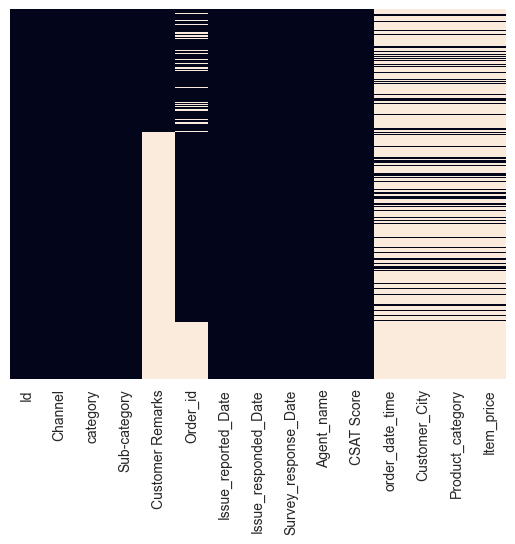

In [3]:
orders_data = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.1%20data%20integration/data/orders.csv', index_col=0)

orders_data = orders_data.rename(columns={
    'Id': 'Order_id'
})

data123_orders = data123.merge(orders_data, on='Order_id', how='left')
sns.heatmap(data123_orders.isnull(), yticklabels=False, cbar=False)

In [9]:
agent_data = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.1%20data%20integration/data/agents.csv', index_col=0)
# agent_data = agent_data.rename(columns={
#     'Agent': 'Agent_name'
# })

agent_data['Agent_name'] = agent_data['Agent'].apply(lambda x: f'{x.split()[0][0]}. {x.split()[1]}' if isinstance(x, str) else np.NAN)
data123_orders_agents = data123_orders.merge(agent_data, on='Agent_name', how='left', copy=False)
data123_orders_agents.head()
# 1. считаем количество
agent_counts = agent_data.Agent_name.value_counts().rename('agent_count')

# 2. merge счетчиков
data_with_agent_numbers = data123_orders.merge(
    agent_counts,
    left_on='Agent_name',
    right_index=True,
    how='left'
)

# 3. фильтруем
data_with_agent_numbers['Agent_name'] = data_with_agent_numbers['Agent_name'].where(
    data_with_agent_numbers['agent_count'] == 1,
    np.nan
)

# 4. финальный merge
data_with_agents = data_with_agent_numbers.merge(
    agent_data,
    how='left',
    on='Agent_name'
)

data_with_agents = data_with_agents.drop(['Agent_name', 'agent_count'], axis=1)

print(data_with_agents.isnull().sum())
print(data_with_agents[data_with_agents['Agent'].isnull()].head())
print(data_with_agent_numbers['Agent_name'].isnull().sum())
print(data_with_agents['Agent'].isnull().sum())
# print(agent_data['Agent_name'].nunique())
# print(data_with_agent_numbers['Agent_name'].nunique())

Id                          0
Channel                     0
category                    0
Sub-category                0
Customer Remarks        57482
Order_id                19246
Issue_reported_Date         0
Issue_responded_Date        0
Survey_response_Date        0
CSAT Score                  0
order_date_time         68956
Customer_City           69090
Product_category        68974
Item_price              68964
Agent                   17158
Supervisor              17158
Manager                 17158
Tenure Bucket           17158
Shift                   17158
dtype: int64
                                      Id  Channel         category  \
4   abd330a8-f3e2-4b7a-b14a-4ed35c4ec023  Inbound          Returns   
10  43d11f06-356e-4553-bf02-c895c509267c  Inbound          Returns   
33  4a9edd7c-5ee9-4fef-ac43-26efb5b00226  Inbound          Returns   
36  18524eb6-465c-469f-8f84-f99a242e2f87  Inbound  Product Queries   
38  46ecb028-4f6d-48e4-adff-bbf2c94821b5  Inbound          Returns 

C:\Users\Artem\AppData\Local\Temp\ipykernel_27652\3120367497.py:7: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  data123_orders_agents = data123_orders.merge(agent_data, on='Agent_name', how='left', copy=False)
